Using device: cuda


/root/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
100%|██████████| 1019/1019 [00:40<00:00, 25.41it/s]


Epoch 1/10 | Train Loss: 0.2333 Acc: 0.9041 | Val Loss: 0.9288 Acc: 0.8380


100%|██████████| 1019/1019 [00:44<00:00, 22.71it/s]


Epoch 2/10 | Train Loss: 0.1558 Acc: 0.9344 | Val Loss: 23.9737 Acc: 0.5979


...

Epoch 8/10 | Train Loss: 0.1203 Acc: 0.9478 | Val Loss: 0.1171 Acc: 0.9490


100%|██████████| 1019/1019 [00:43<00:00, 23.37it/s]


Epoch 9/10 | Train Loss: 0.1194 Acc: 0.9473 | Val Loss: 0.1167 Acc: 0.9494


100%|██████████| 1019/1019 [00:47<00:00, 21.31it/s]


Epoch 10/10 | Train Loss: 0.1177 Acc: 0.9480 | Val Loss: 0.1130 Acc: 0.9488


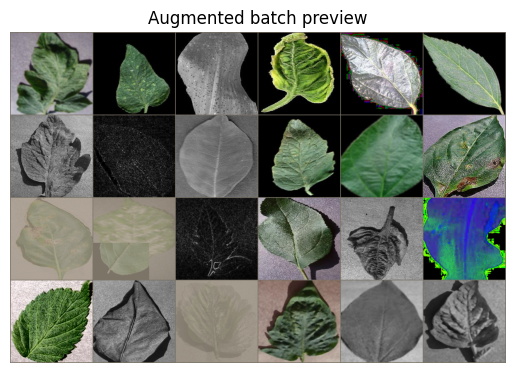

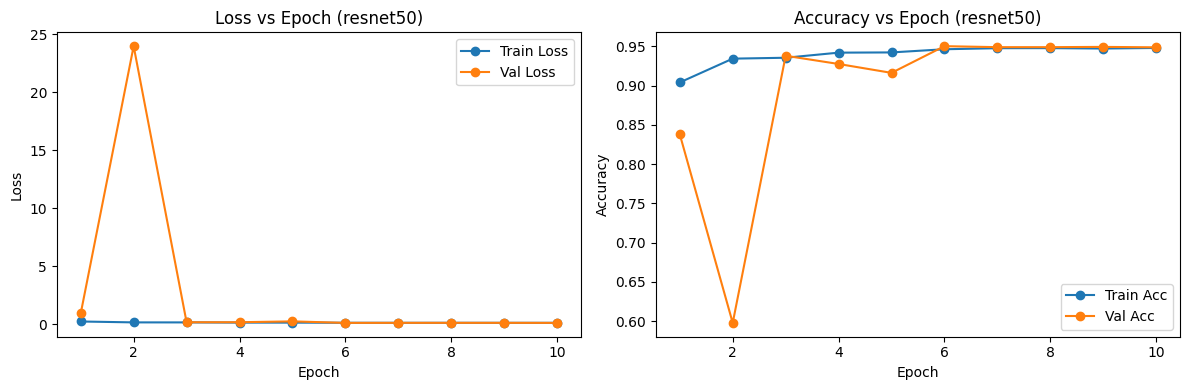

100%|██████████| 510/510 [00:20<00:00, 24.68it/s]


Test Loss: 0.1161 Acc: 0.9511


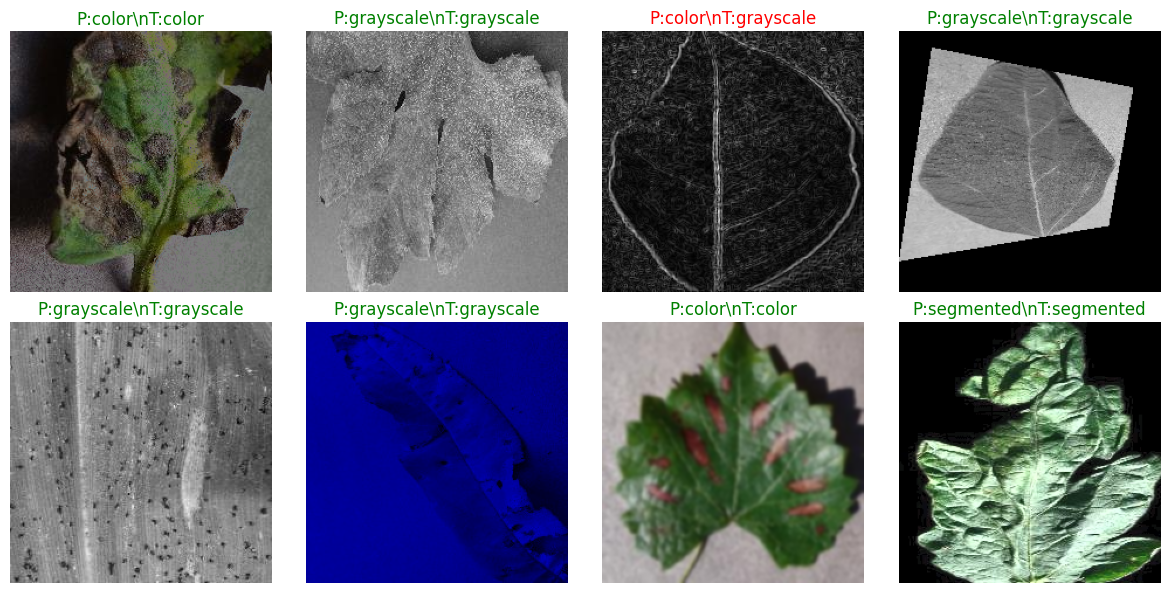

In [1]:
# 主程序
import torch
import torch.nn as nn
import torch.optim as optim

from pvlib.config import ExperimentConfig, set_seed
from pvlib.data import (
    AUG_TYPES,
    RandomAugImageFolder,
    create_dataloaders,
    load_base_dataset,
    make_grid_from_loader,
    show_batch,
    split_dataset,
    )
from pvlib.models import get_model
from pvlib.train import eval_model, plot_train_curves, train_and_record, visualize_predictions

cfg = ExperimentConfig(
    data_path='plantvillage dataset',
    img_size=256,
    crop_size=224,
    batch_size=32,
    num_epochs=10,
    num_workers=0,
    seed=42,
    )

set_seed(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

base_dataset, classes = load_base_dataset(cfg.data_path)
aug_dataset = RandomAugImageFolder(
    samples=base_dataset.samples,
    aug_types=AUG_TYPES,
    num_classes=len(classes),
    img_size=cfg.img_size,
    crop_size=cfg.crop_size,
    )

train_dataset, val_dataset, test_dataset = split_dataset(
    aug_dataset,
    seed=cfg.seed,
    val_ratio=0.2,
    test_ratio=0.1,
    )

train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    device=device,
    )

grid = make_grid_from_loader(train_loader, n=24)
show_batch(grid, title='Augmented batch preview')

selected_model = 'resnet50'
model = get_model(selected_model, num_classes=len(classes), crop_size=cfg.crop_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = train_and_record(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    cfg.num_epochs,
    selected_model,
    device,
    )
plot_train_curves(history, selected_model)

model.load_state_dict(torch.load(f'best_model_{selected_model}.pth', map_location=device))
test_loss, test_acc = eval_model(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')

visualize_predictions(model, val_loader, classes, device, num_images=8)

## 结构化入口

In [2]:
# 可选：多模型批量训练与对比（默认关闭）
import importlib
import pvlib.train as train_mod

train_mod = importlib.reload(train_mod)
train_multiple_models = train_mod.train_multiple_models
plot_model_val_compare = train_mod.plot_model_val_compare

RUN_MULTI_MODEL = False
model_choices = [
    'simple', 'vgg16', 'vgg19', 'resnet18', 'resnet50',
    'inception', 'mobilenet', 'resnet_inception', 'inception_resnet_v2',
]

if RUN_MULTI_MODEL:
    multi_results = train_multiple_models(
        model_names=model_choices,
        get_model_fn=get_model,
        num_classes=len(classes),
        crop_size=cfg.crop_size,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=cfg.num_epochs,
        device=device,
    )
    plot_model_val_compare(multi_results)
else:
    print('Skip multi-model training. Set RUN_MULTI_MODEL=True to enable.')

Skip multi-model training. Set RUN_MULTI_MODEL=True to enable.


Pruning sparsity summary (first 5 layers):
{'layer': 'conv1', 'nonzero': 7526.0, 'total': 9408.0, 'sparsity': 0.20004251700680276}
{'layer': 'layer1.0.conv1', 'nonzero': 3277.0, 'total': 4096.0, 'sparsity': 0.199951171875}
{'layer': 'layer1.0.conv2', 'nonzero': 29491.0, 'total': 36864.0, 'sparsity': 0.2000054253472222}
{'layer': 'layer1.0.conv3', 'nonzero': 13107.0, 'total': 16384.0, 'sparsity': 0.20001220703125}
{'layer': 'layer1.0.downsample.0', 'nonzero': 13107.0, 'total': 16384.0, 'sparsity': 0.20001220703125}


100%|██████████| 1019/1019 [00:44<00:00, 22.71it/s]


[Prune Finetune] Epoch 1/10 | Train Loss: 0.1265 Acc: 0.9449 | Val Loss: 0.1324 Acc: 0.9461


100%|██████████| 1019/1019 [00:42<00:00, 24.06it/s]


[Prune Finetune] Epoch 2/10 | Train Loss: 0.1250 Acc: 0.9461 | Val Loss: 0.2365 Acc: 0.9203


...

[Quant Finetune] Epoch 9/10 | Train Loss: 0.1074 Acc: 0.9503 | Val Loss: 0.1149 Acc: 0.9488


100%|██████████| 1019/1019 [00:44<00:00, 22.93it/s]


[Quant Finetune] Epoch 10/10 | Train Loss: 0.1064 Acc: 0.9506 | Val Loss: 0.2491 Acc: 0.9102
conv1 compression ratio: 1.06
layer1.0.conv1 compression ratio: 1.02
layer1.0.conv2 compression ratio: 1.10
layer1.0.conv3 compression ratio: 1.07
layer1.0.downsample.0 compression ratio: 1.09
layer1.1.conv1 compression ratio: 1.07
layer1.1.conv2 compression ratio: 1.07
layer1.1.conv3 compression ratio: 1.07
layer1.2.conv1 compression ratio: 1.07
layer1.2.conv2 compression ratio: 1.09
layer1.2.conv3 compression ratio: 1.06
layer2.0.conv1 compression ratio: 1.09
layer2.0.conv2 compression ratio: 1.11
layer2.0.conv3 compression ratio: 1.11
layer2.0.downsample.0 compression ratio: 1.10
layer2.1.conv1 compression ratio: 1.10
layer2.1.conv2 compression ratio: 1.12
layer2.1.conv3 compression ratio: 1.09
layer2.2.conv1 compression ratio: 1.11
layer2.2.conv2 compression ratio: 1.11
layer2.2.conv3 compression ratio: 1.09
layer2.3.conv1 compression ratio: 1.10
layer2.3.conv2 compression ratio: 1.09
layer

100%|██████████| 510/510 [00:22<00:00, 22.97it/s]

Compressed Test Loss: 0.2466 Acc: 0.9119


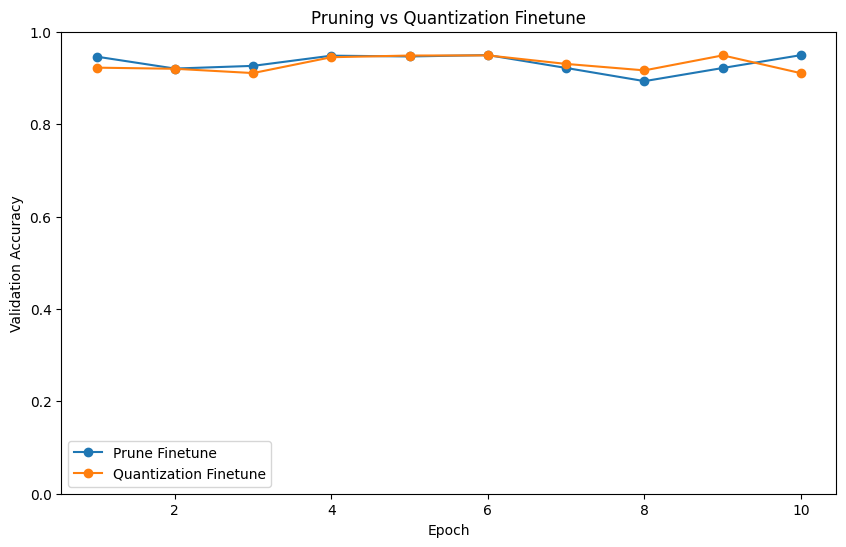

                 storage_kb
original       91620.750000
prune         159639.125000
quantization   22958.187500
huffman        19350.583984


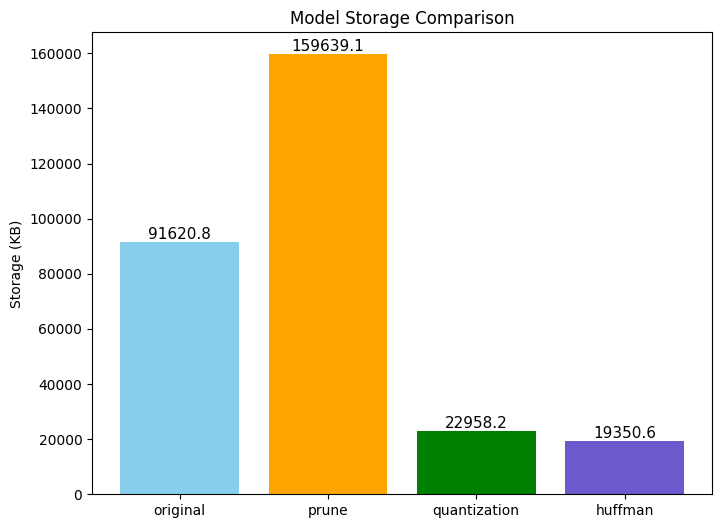

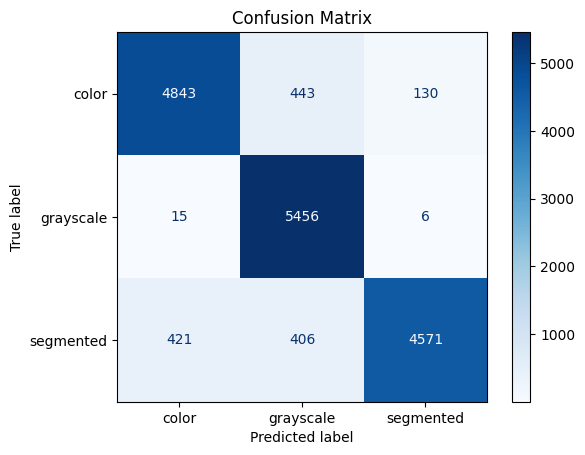

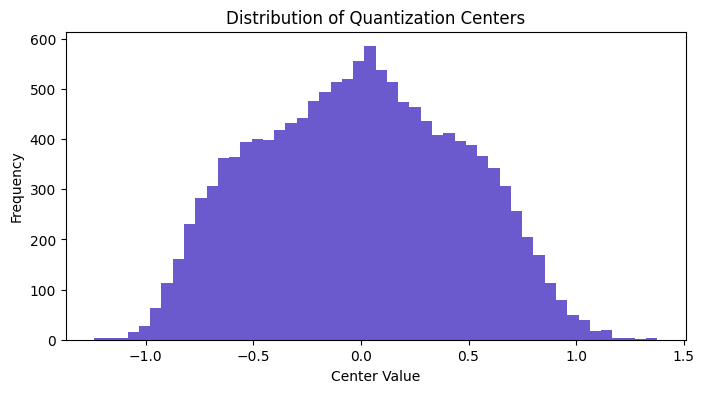

In [3]:
# 可选：Deep Compression + 评估分析
import torch.optim as optim
from pvlib.compression import (
    apply_conv_pruning,
    build_quantized_dict,
    collect_conv_sparsity,
    compute_storage_breakdown,
    finetune_model,
    load_quantized_weights,
    plot_confusion,
    plot_finetune_compare,
    plot_quant_centers,
    plot_storage_breakdown,
    print_huffman_like_ratio,
    )
from pvlib.train import train_one_epoch

RUN_COMPRESSION = True
NUM_EPOCHS_FINETUNE = 10

if RUN_COMPRESSION:
    # 1) 剪枝 + 微调
    apply_conv_pruning(model, amount=0.2)
    sparsity_stats = collect_conv_sparsity(model)
    print('Pruning sparsity summary (first 5 layers):')
    for row in sparsity_stats[:5]:
        print(row)

    criterion_comp = nn.CrossEntropyLoss()
    optimizer_comp = optim.Adam(model.parameters(), lr=1e-3)
    scheduler_comp = optim.lr_scheduler.StepLR(optimizer_comp, step_size=5, gamma=0.5)
    prune_accs = finetune_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_comp,
        optimizer=optimizer_comp,
        scheduler=scheduler_comp,
        num_epochs=NUM_EPOCHS_FINETUNE,
        train_one_epoch_fn=train_one_epoch,
        eval_model_fn=eval_model,
        device=device,
        stage_name='Prune Finetune',
    )

    # 2) 量化 + 微调
    quantized_dict = build_quantized_dict(model, n_clusters=256)
    load_quantized_weights(model, quantized_dict)
    optimizer_comp = optim.Adam(model.parameters(), lr=1e-3)
    scheduler_comp = optim.lr_scheduler.StepLR(optimizer_comp, step_size=5, gamma=0.5)
    quant_accs = finetune_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_comp,
        optimizer=optimizer_comp,
        scheduler=scheduler_comp,
        num_epochs=NUM_EPOCHS_FINETUNE,
        train_one_epoch_fn=train_one_epoch,
        eval_model_fn=eval_model,
        device=device,
        stage_name='Quant Finetune',
    )

    # 3) 压缩率与测试集评估
    print_huffman_like_ratio(quantized_dict)
    torch.save(model.state_dict(), 'compressed_model.pth')
    comp_test_loss, comp_test_acc = eval_model(model, test_loader, criterion_comp, device)
    print(f'Compressed Test Loss: {comp_test_loss:.4f} Acc: {comp_test_acc:.4f}')

    # 4) 可视化分析
    plot_finetune_compare(prune_accs, quant_accs)
    storage_df = compute_storage_breakdown(model, quantized_dict)
    print(storage_df)
    plot_storage_breakdown(storage_df)
    plot_confusion(model, test_loader, classes, device)
    plot_quant_centers(quantized_dict)
else:
    print('Skip compression pipeline. Set RUN_COMPRESSION=True to enable.')

## 论文级实验套件（IEEE 风格）

> 下面 4 个单元分别对应：主结果对比、增强消融、压缩权衡、误差分析。默认都可按开关控制，避免一次性跑太久。

In [4]:
# 1) 主结果对比（SOTA风格）：Main Results Table
import copy
import pandas as pd
import torch.optim as optim

from pvlib.models import get_model
from pvlib.train import train_and_record
from pvlib.paper_eval import collect_predictions, compute_main_metrics

RUN_SOTA_MAIN = False
SOTA_MODELS = ['resnet18', 'resnet50', 'mobilenet', 'inception_resnet_v2']
MY_METHOD_NAME = 'resnet50_full_aug'  # 你的方案名称（可改）

main_rows = []
if RUN_SOTA_MAIN:
    for model_name in SOTA_MODELS:
        print(f'\n=== Train baseline: {model_name} ===')
        m = get_model(model_name, num_classes=len(classes), crop_size=cfg.crop_size).to(device)
        criterion_m = nn.CrossEntropyLoss()
        optimizer_m = optim.Adam(m.parameters(), lr=1e-3)
        scheduler_m = optim.lr_scheduler.StepLR(optimizer_m, step_size=5, gamma=0.5)

        _ = train_and_record(
            model=m,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion_m,
            optimizer=optimizer_m,
            scheduler=scheduler_m,
            num_epochs=cfg.num_epochs,
            model_name=model_name,
            device=device,
        )
        m.load_state_dict(torch.load(f'best_model_{model_name}.pth', map_location=device))
        y_true, y_pred = collect_predictions(m, test_loader, device)
        metrics = compute_main_metrics(y_true, y_pred)
        metrics['Model'] = model_name
        main_rows.append(metrics)

    # 你的方案（这里默认使用当前主流程训练出的 model 作为你的方案）
    y_true_my, y_pred_my = collect_predictions(model, test_loader, device)
    my_metrics = compute_main_metrics(y_true_my, y_pred_my)
    my_metrics['Model'] = MY_METHOD_NAME
    main_rows.append(my_metrics)

    main_df = pd.DataFrame(main_rows)[['Model', 'Top1_Accuracy', 'Macro_F1', 'Macro_Precision', 'Macro_Recall']]
    main_df = main_df.sort_values('Top1_Accuracy', ascending=False).reset_index(drop=True)
    print('\nMain Results Table:')
    print(main_df)
    main_df.to_csv('main_results_table.csv', index=False)
    print('Saved: main_results_table.csv')
else:
    print('Skip SOTA main results. Set RUN_SOTA_MAIN=True to enable.')

Skip SOTA main results. Set RUN_SOTA_MAIN=True to enable.


/root/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



=== Ablation: no_aug ===


100%|██████████| 1019/1019 [00:30<00:00, 33.46it/s]


Epoch 1/10 | Train Loss: 0.0723 Acc: 0.9745 | Val Loss: 0.0423 Acc: 0.9828


100%|██████████| 1019/1019 [00:27<00:00, 37.08it/s]


...

Epoch 8/10 | Train Loss: 0.1190 Acc: 0.9476 | Val Loss: 0.2436 Acc: 0.9139


100%|██████████| 1019/1019 [00:44<00:00, 22.84it/s]


Epoch 9/10 | Train Loss: 0.1182 Acc: 0.9466 | Val Loss: 0.2865 Acc: 0.9256


100%|██████████| 1019/1019 [00:45<00:00, 22.63it/s]


Epoch 10/10 | Train Loss: 0.1172 Acc: 0.9487 | Val Loss: 0.3042 Acc: 0.8859

Ablation Table:
            Policy  Top1_Accuracy  Macro_F1  Macro_Precision  Macro_Recall  \
0           no_aug       0.984286  0.984222         0.984270      0.984219   
1         base_aug       0.986066  0.986009         0.986145      0.986017   
2  base_aug_mixcut       0.972132  0.972002         0.972208      0.972049   
3         full_aug       0.950709  0.950810         0.951826      0.950928   

   Best_Val_Acc  
0      0.983458  
1      0.985944  
2      0.973299  
3      0.949237  
Saved: ablation_table.csv


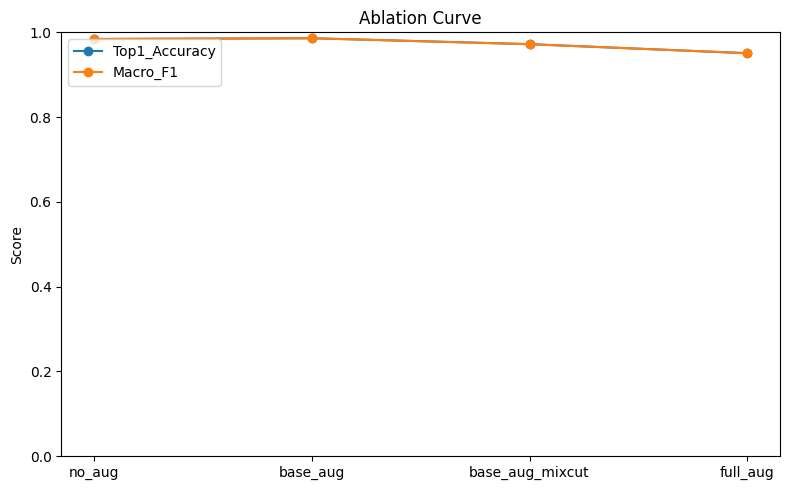

In [5]:
# 2) 增强消融（Ablation）：表格 + 曲线
import pandas as pd
import torch.optim as optim
import matplotlib.pyplot as plt

from pvlib.data import AUG_TYPES, RandomAugImageFolder, split_dataset, create_dataloaders
from pvlib.models import get_model
from pvlib.train import train_and_record
from pvlib.paper_eval import collect_predictions, compute_main_metrics

RUN_ABLATION = True
ABLATION_MODEL = 'resnet50'
BASE_AUG = ['original', 'random_vflip', 'rotate15', 'colorjitter', 'randomaffine', 'randomresizedcrop']
BASE_MIXCUT = BASE_AUG + ['mixup', 'cutmix']
FULL_AUG = AUG_TYPES

ablation_policies = {
    'no_aug': ['original'],
    'base_aug': BASE_AUG,
    'base_aug_mixcut': BASE_MIXCUT,
    'full_aug': FULL_AUG,
}

ablation_rows = []
if RUN_ABLATION:
    for policy_name, policy_aug in ablation_policies.items():
        print(f'\n=== Ablation: {policy_name} ===')
        ds = RandomAugImageFolder(
            samples=base_dataset.samples,
            aug_types=policy_aug,
            num_classes=len(classes),
            img_size=cfg.img_size,
            crop_size=cfg.crop_size,
        )
        tr_ds, va_ds, te_ds = split_dataset(ds, seed=cfg.seed, val_ratio=0.2, test_ratio=0.1)
        tr_ld, va_ld, te_ld = create_dataloaders(
            tr_ds, va_ds, te_ds,
            batch_size=cfg.batch_size,
            num_workers=cfg.num_workers,
            device=device,
        )

        m = get_model(ABLATION_MODEL, num_classes=len(classes), crop_size=cfg.crop_size).to(device)
        criterion_a = nn.CrossEntropyLoss()
        optimizer_a = optim.Adam(m.parameters(), lr=1e-3)
        scheduler_a = optim.lr_scheduler.StepLR(optimizer_a, step_size=5, gamma=0.5)

        hist = train_and_record(
            model=m,
            train_loader=tr_ld,
            val_loader=va_ld,
            criterion=criterion_a,
            optimizer=optimizer_a,
            scheduler=scheduler_a,
            num_epochs=cfg.num_epochs,
            model_name=f'{ABLATION_MODEL}_{policy_name}',
            device=device,
        )

        m.load_state_dict(torch.load(f'best_model_{ABLATION_MODEL}_{policy_name}.pth', map_location=device))
        y_true, y_pred = collect_predictions(m, te_ld, device)
        metrics = compute_main_metrics(y_true, y_pred)
        metrics['Policy'] = policy_name
        metrics['Best_Val_Acc'] = max(hist['val_accs']) if hist['val_accs'] else 0.0
        ablation_rows.append(metrics)

    ablation_df = pd.DataFrame(ablation_rows)[['Policy', 'Top1_Accuracy', 'Macro_F1', 'Macro_Precision', 'Macro_Recall', 'Best_Val_Acc']]
    print('\nAblation Table:')
    print(ablation_df)
    ablation_df.to_csv('ablation_table.csv', index=False)
    print('Saved: ablation_table.csv')

    plt.figure(figsize=(8, 5))
    plt.plot(ablation_df['Policy'], ablation_df['Top1_Accuracy'], '-o', label='Top1_Accuracy')
    plt.plot(ablation_df['Policy'], ablation_df['Macro_F1'], '-o', label='Macro_F1')
    plt.ylabel('Score')
    plt.title('Ablation Curve')
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Skip ablation. Set RUN_ABLATION=True to enable.')

In [6]:
# 3) 压缩权衡（Compression Trade-off）：表格
import copy
import pandas as pd
import torch.optim as optim

from pvlib.compression import apply_conv_pruning, build_quantized_dict, load_quantized_weights
from pvlib.paper_eval import (
    collect_predictions,
    compute_main_metrics,
    model_param_count,
    model_size_mb,
    huffman_estimated_size_mb,
    inference_latency_ms_per_img,
 )

RUN_TRADEOFF = True
RUN_TRADEOFF_FINETUNE = True
TRADEOFF_FINETUNE_EPOCHS = 3

if RUN_TRADEOFF:
    criterion_t = nn.CrossEntropyLoss()
    tradeoff_rows = []

    # A) Original
    m_original = copy.deepcopy(model).to(device)
    y_true, y_pred = collect_predictions(m_original, test_loader, device)
    mt = compute_main_metrics(y_true, y_pred)
    tradeoff_rows.append({
        'Method': 'Original',
        'Accuracy': mt['Top1_Accuracy'],
        'Macro_F1': mt['Macro_F1'],
        'Model_Size_MB': model_size_mb(m_original),
        'Params_M': model_param_count(m_original) / 1e6,
        'Latency_ms_per_img': inference_latency_ms_per_img(m_original, test_loader, device),
    })

    # B) Pruning
    m_prune = copy.deepcopy(model).to(device)
    apply_conv_pruning(m_prune, amount=0.2)
    if RUN_TRADEOFF_FINETUNE:
        optimizer_p = optim.Adam(m_prune.parameters(), lr=1e-3)
        scheduler_p = optim.lr_scheduler.StepLR(optimizer_p, step_size=2, gamma=0.5)
        for _ in range(TRADEOFF_FINETUNE_EPOCHS):
            _ = train_one_epoch(m_prune, train_loader, criterion_t, optimizer_p, device)
            scheduler_p.step()
    y_true, y_pred = collect_predictions(m_prune, test_loader, device)
    mt = compute_main_metrics(y_true, y_pred)
    tradeoff_rows.append({
        'Method': 'Pruning',
        'Accuracy': mt['Top1_Accuracy'],
        'Macro_F1': mt['Macro_F1'],
        'Model_Size_MB': model_size_mb(m_prune),
        'Params_M': model_param_count(m_prune) / 1e6,
        'Latency_ms_per_img': inference_latency_ms_per_img(m_prune, test_loader, device),
    })

    # C) Quantization (weight sharing)
    m_quant = copy.deepcopy(model).to(device)
    qd_quant = build_quantized_dict(m_quant, n_clusters=256)
    load_quantized_weights(m_quant, qd_quant)
    if RUN_TRADEOFF_FINETUNE:
        optimizer_q = optim.Adam(m_quant.parameters(), lr=1e-3)
        scheduler_q = optim.lr_scheduler.StepLR(optimizer_q, step_size=2, gamma=0.5)
        for _ in range(TRADEOFF_FINETUNE_EPOCHS):
            _ = train_one_epoch(m_quant, train_loader, criterion_t, optimizer_q, device)
            scheduler_q.step()
    y_true, y_pred = collect_predictions(m_quant, test_loader, device)
    mt = compute_main_metrics(y_true, y_pred)
    tradeoff_rows.append({
        'Method': 'Quantization',
        'Accuracy': mt['Top1_Accuracy'],
        'Macro_F1': mt['Macro_F1'],
        'Model_Size_MB': model_size_mb(m_quant),
        'Params_M': model_param_count(m_quant) / 1e6,
        'Latency_ms_per_img': inference_latency_ms_per_img(m_quant, test_loader, device),
    })

    # D) Pruning + Quantization (+Huffman estimated size)
    m_pq = copy.deepcopy(model).to(device)
    apply_conv_pruning(m_pq, amount=0.2)
    qd_pq = build_quantized_dict(m_pq, n_clusters=256)
    load_quantized_weights(m_pq, qd_pq)
    if RUN_TRADEOFF_FINETUNE:
        optimizer_pq = optim.Adam(m_pq.parameters(), lr=1e-3)
        scheduler_pq = optim.lr_scheduler.StepLR(optimizer_pq, step_size=2, gamma=0.5)
        for _ in range(TRADEOFF_FINETUNE_EPOCHS):
            _ = train_one_epoch(m_pq, train_loader, criterion_t, optimizer_pq, device)
            scheduler_pq.step()
    y_true, y_pred = collect_predictions(m_pq, test_loader, device)
    mt = compute_main_metrics(y_true, y_pred)
    tradeoff_rows.append({
        'Method': 'Pruning+Quantization(+Huffman)',
        'Accuracy': mt['Top1_Accuracy'],
        'Macro_F1': mt['Macro_F1'],
        'Model_Size_MB': huffman_estimated_size_mb(qd_pq),
        'Params_M': model_param_count(m_pq) / 1e6,
        'Latency_ms_per_img': inference_latency_ms_per_img(m_pq, test_loader, device),
    })

    tradeoff_df = pd.DataFrame(tradeoff_rows)
    print('\nCompression Trade-off Table:')
    print(tradeoff_df)
    tradeoff_df.to_csv('compression_tradeoff_table.csv', index=False)
    print('Saved: compression_tradeoff_table.csv')
else:
    print('Skip compression trade-off. Set RUN_TRADEOFF=True to enable.')

100%|██████████| 3564/3564 [03:46<00:00, 15.74it/s]



Compression Trade-off Table:
                           Method  Accuracy  Macro_F1  Model_Size_MB  \
0                        Original  0.911178  0.910580       0.000000   
1                         Pruning  0.947333  0.946978       0.000000   
2                    Quantization  0.918667  0.918546       0.000000   
3  Pruning+Quantization(+Huffman)  0.923516  0.924620      17.821441   

    Params_M  Latency_ms_per_img  
0  23.514179            0.246336  
1  23.514179            0.251812  
2  23.514179            0.247800  
3  23.514179            0.250866  
Saved: compression_tradeoff_table.csv


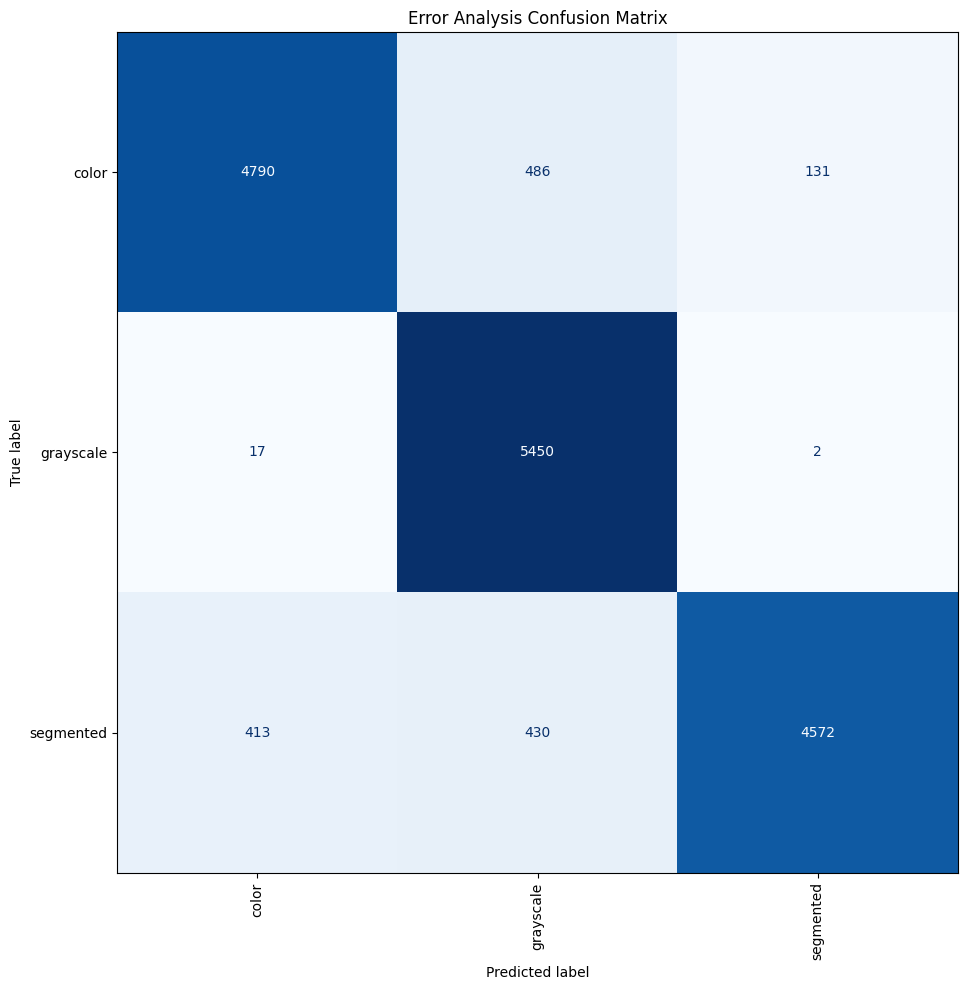


Per-class metrics (sorted by F1 ascending):
       class  precision    recall        f1  support
0      color   0.917625  0.885889  0.901477     5407
1  segmented   0.971732  0.844321  0.903557     5415
2  grayscale   0.856111  0.996526  0.920997     5469
Saved: per_class_metrics.csv

Top-10 confused class pairs:
  true_class pred_class  count
0      color  grayscale    486
1  segmented  grayscale    430
2  segmented      color    413
3      color  segmented    131
4  grayscale      color     17
5  grayscale  segmented      2
Saved: top_confused_pairs.csv


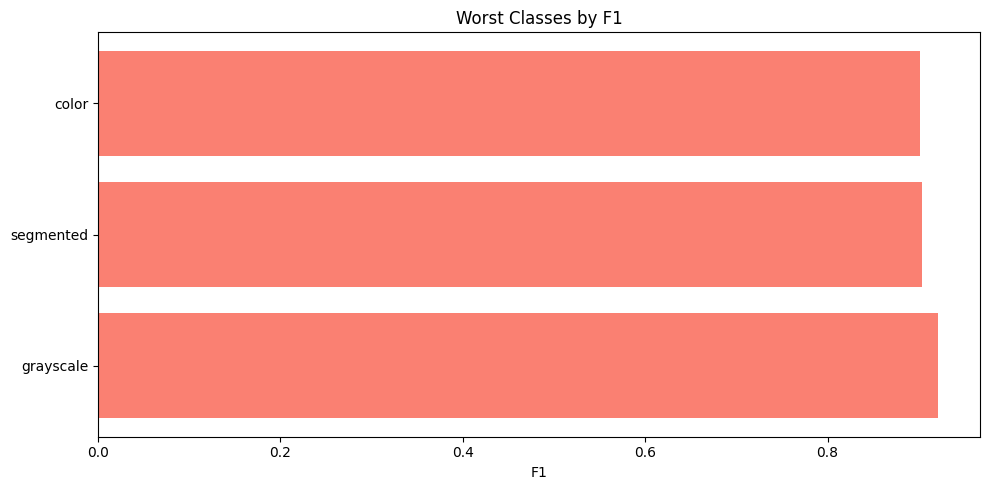


Discussion template:
- Check if confused pairs share similar color/texture symptoms.
- Check class imbalance using support column in per_class_metrics.csv.
- Check whether stronger augmentations hurt fine-grained classes.


In [7]:
# 4) 类别级分析（Error Analysis）：混淆矩阵 + 每类指标 + Top-k 易混类别
import matplotlib.pyplot as plt
from pvlib.paper_eval import (
    collect_predictions,
    per_class_metrics_df,
    plot_confusion,
    top_confused_pairs,
 )

RUN_ERROR_ANALYSIS = True
TOPK_CONFUSED = 10

if RUN_ERROR_ANALYSIS:
    y_true_e, y_pred_e = collect_predictions(model, test_loader, device)

    # 1) 混淆矩阵
    plot_confusion(y_true_e, y_pred_e, classes, title='Error Analysis Confusion Matrix')

    # 2) 每类 Precision / Recall / F1
    class_df = per_class_metrics_df(y_true_e, y_pred_e, classes)
    class_df = class_df.sort_values('f1', ascending=True).reset_index(drop=True)
    print('\nPer-class metrics (sorted by F1 ascending):')
    print(class_df.head(15))
    class_df.to_csv('per_class_metrics.csv', index=False)
    print('Saved: per_class_metrics.csv')

    # 3) 最易混类别 Top-k
    confused_df = top_confused_pairs(y_true_e, y_pred_e, classes, k=TOPK_CONFUSED)
    print(f'\nTop-{TOPK_CONFUSED} confused class pairs:')
    print(confused_df)
    confused_df.to_csv('top_confused_pairs.csv', index=False)
    print('Saved: top_confused_pairs.csv')

    # 4) 可视化：最差类别 F1
    worst_n = min(10, len(class_df))
    worst_df = class_df.head(worst_n)
    plt.figure(figsize=(10, 5))
    plt.barh(worst_df['class'], worst_df['f1'], color='salmon')
    plt.xlabel('F1')
    plt.title('Worst Classes by F1')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # 5) 原因讨论（可直接写进论文）
    print('\nDiscussion template:')
    print('- Check if confused pairs share similar color/texture symptoms.')
    print('- Check class imbalance using support column in per_class_metrics.csv.')
    print('- Check whether stronger augmentations hurt fine-grained classes.')
else:
    print('Skip error analysis. Set RUN_ERROR_ANALYSIS=True to enable.')

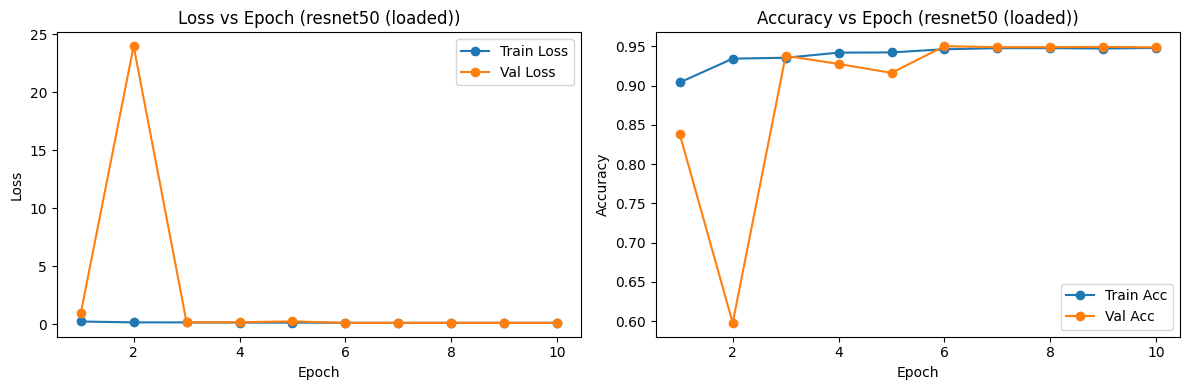

Loaded history from artifacts/history_resnet50.json


In [8]:
# 重启内核后：不重训，直接加载历史并画训练曲线
from pvlib.train import load_history, plot_train_curves

# 和你训练时的模型名保持一致
HISTORY_MODEL_NAME = 'resnet50'
HISTORY_DIR = 'artifacts'

history_loaded = load_history(HISTORY_MODEL_NAME, history_dir=HISTORY_DIR)
plot_train_curves(history_loaded, f'{HISTORY_MODEL_NAME} (loaded)')
print(f'Loaded history from {HISTORY_DIR}/history_{HISTORY_MODEL_NAME}.json')

## 重启后快速评估（不训练）

这个单元用于内核重启后快速恢复评估：加载模型权重并直接输出指标与图表。

Using device: cuda


/root/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
100%|██████████| 510/510 [00:22<00:00, 23.12it/s]


Test Loss: 0.1153 Acc: 0.9494
Main metrics: {'Top1_Accuracy': 0.946780430912774, 'Macro_Precision': 0.9492128810735995, 'Macro_Recall': 0.9469477781361023, 'Macro_F1': 0.9469648269128879}
Per-class metrics (first 10 rows):
       class  precision    recall        f1  support
0      color   0.892629  0.959013  0.924631     5392
1  grayscale   0.994385  0.905257  0.947731     5478
2  segmented   0.960624  0.976573  0.968533     5421
Top-10 confused pairs:
  true_class pred_class  count
0  grayscale      color    502
1      color  segmented    200
2  segmented      color    120
3      color  grayscale     21
4  grayscale  segmented     17
5  segmented  grayscale      7


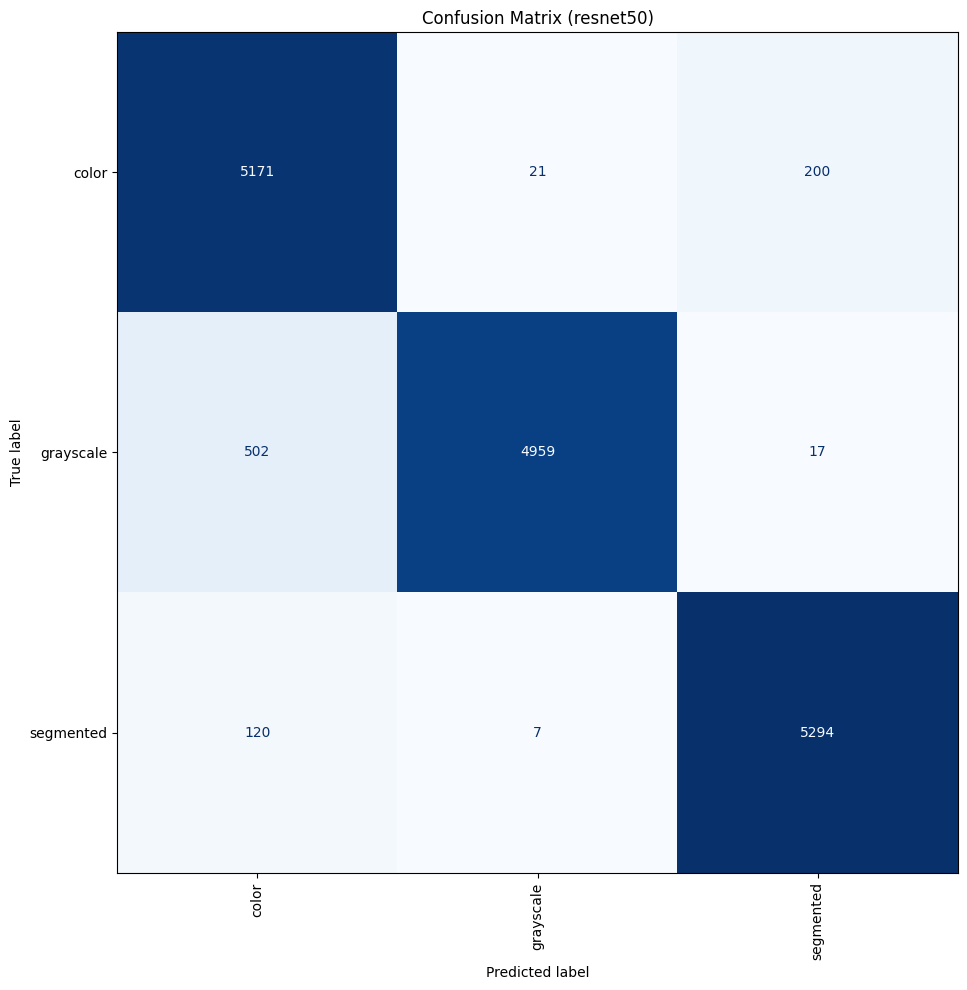

In [9]:
# 重启后快速评估：不训练，直接加载 best_model 并输出指标
import torch
import torch.nn as nn

from pvlib.config import ExperimentConfig, set_seed
from pvlib.data import AUG_TYPES, RandomAugImageFolder, create_dataloaders, load_base_dataset, split_dataset
from pvlib.models import get_model
from pvlib.train import eval_model
from pvlib.paper_eval import collect_predictions, compute_main_metrics, per_class_metrics_df, plot_confusion, top_confused_pairs

# 评估配置（按需修改）
EVAL_MODEL_NAME = 'resnet50'
EVAL_WEIGHT_PATH = f'best_model_{EVAL_MODEL_NAME}.pth'
EVAL_TOPK_CONFUSED = 10

cfg_eval = ExperimentConfig(
    data_path='plantvillage dataset',
    img_size=256,
    crop_size=224,
    batch_size=32,
    num_epochs=10,
    num_workers=0,
    seed=42,
    )

set_seed(cfg_eval.seed)
device_eval = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device_eval)

# 仅重建数据加载器（不训练）
base_dataset_eval, classes_eval = load_base_dataset(cfg_eval.data_path)
aug_dataset_eval = RandomAugImageFolder(
    samples=base_dataset_eval.samples,
    aug_types=AUG_TYPES,
    num_classes=len(classes_eval),
    img_size=cfg_eval.img_size,
    crop_size=cfg_eval.crop_size,
    )
train_ds_eval, val_ds_eval, test_ds_eval = split_dataset(
    aug_dataset_eval,
    seed=cfg_eval.seed,
    val_ratio=0.2,
    test_ratio=0.1,
    )
_, _, test_loader_eval = create_dataloaders(
    train_ds_eval,
    val_ds_eval,
    test_ds_eval,
    batch_size=cfg_eval.batch_size,
    num_workers=cfg_eval.num_workers,
    device=device_eval,
    )

# 加载已训练权重并评估
model_eval = get_model(EVAL_MODEL_NAME, num_classes=len(classes_eval), crop_size=cfg_eval.crop_size).to(device_eval)
model_eval.load_state_dict(torch.load(EVAL_WEIGHT_PATH, map_location=device_eval))
model_eval.eval()

criterion_eval = nn.CrossEntropyLoss()
test_loss_eval, test_acc_eval = eval_model(model_eval, test_loader_eval, criterion_eval, device_eval)
print(f'Test Loss: {test_loss_eval:.4f} Acc: {test_acc_eval:.4f}')

# 论文指标与误差分析
y_true_eval, y_pred_eval = collect_predictions(model_eval, test_loader_eval, device_eval)
main_metrics_eval = compute_main_metrics(y_true_eval, y_pred_eval)
print('Main metrics:', main_metrics_eval)

class_metrics_eval = per_class_metrics_df(y_true_eval, y_pred_eval, classes_eval)
print('Per-class metrics (first 10 rows):')
print(class_metrics_eval.head(10))

confused_pairs_eval = top_confused_pairs(y_true_eval, y_pred_eval, classes_eval, k=EVAL_TOPK_CONFUSED)
print(f'Top-{EVAL_TOPK_CONFUSED} confused pairs:')
print(confused_pairs_eval)

plot_confusion(y_true_eval, y_pred_eval, classes_eval, title=f'Confusion Matrix ({EVAL_MODEL_NAME})')